<a href="https://colab.research.google.com/github/absars/college/blob/main/airline_sentiment_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (14640, 15)

Columns:
['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

Sentiment distribution:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Sample cleaned tweets:
                                                text  \
0                @VirginAmerica What @dhepburn said.   
1  @VirginAmerica plus you've added commercials t...   
2  @VirginAmerica I didn't today... Must mean I n...   
3  @VirginAmerica it's really aggressive to blast...   
4  @VirginAmerica and it's a really big bad thing...   

                                          clean_text airline_sentiment  
0                                          what said           neutral  
1  plus youve added commercials to the experience...          p

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.6874 - loss: 0.7408 - val_accuracy: 0.7606 - val_loss: 0.6011
Epoch 2/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step - accuracy: 0.8130 - loss: 0.4898 - val_accuracy: 0.7960 - val_loss: 0.5296
Epoch 3/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step - accuracy: 0.8805 - loss: 0.3406 - val_accuracy: 0.7810 - val_loss: 0.5934
Epoch 4/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - accuracy: 0.9137 - loss: 0.2526 - val_accuracy: 0.7759 - val_loss: 0.7060
Epoch 5/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step - accuracy: 0.9336 - loss: 0.2019 - val_accuracy: 0.7734 - val_loss: 0.7782

Test Loss: 0.5324
Test Accuracy: 0.7958
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step

Classification Report:
              precision    recall  f1-score   support

    negative     0.8533    0.8910    0.8718      1835
     neutral     0.6800    0.5758    0.6236       620
    positive     0.6940    0.7146    0.7042       473

    accuracy               

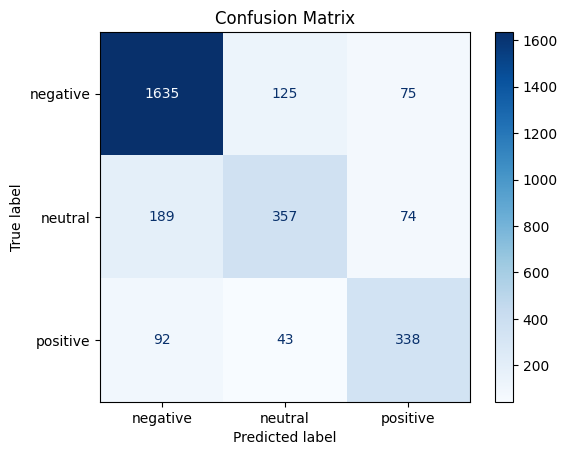

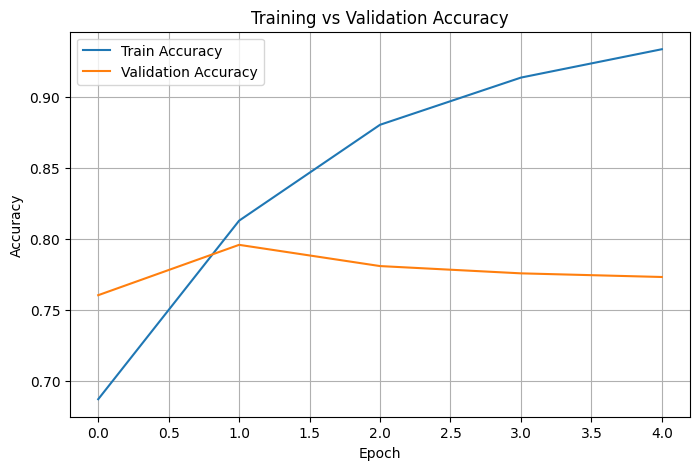

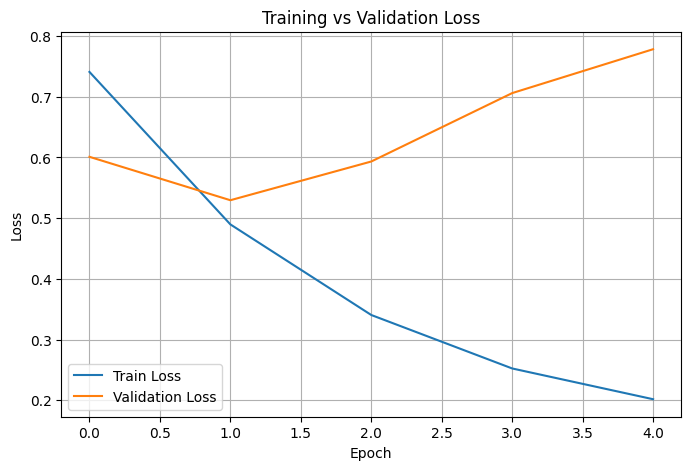

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

Custom Predictions:
Tweet: I love the service from this airline, very smooth flight!
Predicted Sentiment: positive

Tweet: My flight is delayed again and customer service is terrible.
Predicted Sentiment: negative

Tweet: Flight was okay, nothing special.
Predicted Sentiment: negative



In [ ]:
# COMP263 Deep Learning Project
# Airline Sentiment Detection using LSTM
# Dataset: Tweets.csv

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping


# -----------------------------
# 1. Load dataset
# -----------------------------
file_path = "Tweets.csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# Keep only needed columns
df = df[["text", "airline_sentiment"]].dropna()

print("\nSentiment distribution:")
print(df["airline_sentiment"].value_counts())


# -----------------------------
# 2. Text cleaning
# -----------------------------
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)   # remove URLs
    text = re.sub(r"@\w+", "", text)                      # remove mentions
    text = re.sub(r"#", "", text)                         # remove hashtag symbol only
    text = re.sub(r"[^a-zA-Z\s]", "", text)              # keep letters and spaces
    text = re.sub(r"\s+", " ", text).strip()             # remove extra spaces
    return text

df["clean_text"] = df["text"].apply(clean_text)

print("\nSample cleaned tweets:")
print(df[["text", "clean_text", "airline_sentiment"]].head())


# -----------------------------
# 3. Encode labels
# -----------------------------
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["airline_sentiment"])

print("\nLabel mapping:")
for label_name, encoded_value in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"{label_name} -> {encoded_value}")


# -----------------------------
# 4. Train-test split
# -----------------------------
X = df["clean_text"].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# -----------------------------
# 5. Tokenization and padding
# -----------------------------
max_words = 10000
max_len = 40

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

print("\nPadded training shape:", X_train_pad.shape)
print("Padded testing shape:", X_test_pad.shape)


# -----------------------------
# 6. Build LSTM model
# -----------------------------
model = Sequential([
    Embedding(input_dim=max_words, output_dim=64),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(len(label_encoder.classes_), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nModel summary:")
model.summary()


# -----------------------------
# 7. Train model
# -----------------------------
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)


# -----------------------------
# 8. Evaluate model
# -----------------------------
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predictions
y_prob = model.predict(X_test_pad)
y_pred = np.argmax(y_prob, axis=1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    digits=4
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


# -----------------------------
# 9. Plot training history
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


# -----------------------------
# 10. Test on custom examples
# -----------------------------
sample_tweets = [
    "I love the service from this airline, very smooth flight!",
    "My flight is delayed again and customer service is terrible.",
    "Flight was okay, nothing special."
]

sample_clean = [clean_text(tweet) for tweet in sample_tweets]
sample_seq = tokenizer.texts_to_sequences(sample_clean)
sample_pad = pad_sequences(sample_seq, maxlen=max_len, padding="post", truncating="post")

sample_pred = model.predict(sample_pad)
sample_labels = np.argmax(sample_pred, axis=1)
sample_sentiments = label_encoder.inverse_transform(sample_labels)

print("\nCustom Predictions:")
for tweet, sentiment in zip(sample_tweets, sample_sentiments):
    print(f"Tweet: {tweet}")
    print(f"Predicted Sentiment: {sentiment}\n")